In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

sns.set_style("whitegrid")

# [Part 1] 신경망 아키텍처(구조) 도식화 (2 -> 3 -> 1)

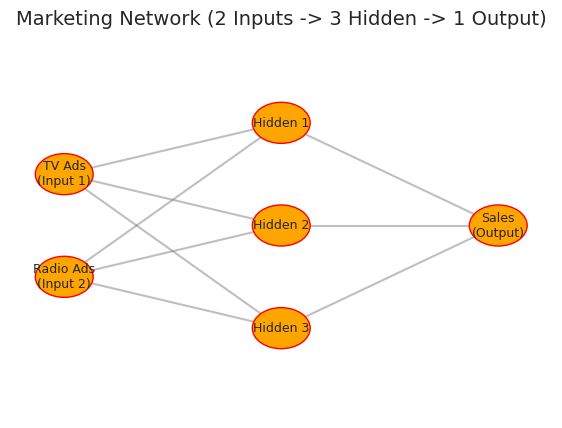

In [2]:
def draw_neural_net(layer_sizes):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.gca()
    ax.axis('off')
    
    left, right, bottom, top = 0.1, 0.9, 0.1, 0.9
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(len(layer_sizes) - 1)
    
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2. + (top + bottom) / 2.
        for m in range(layer_size):
            circle = plt.Circle((n * h_spacing + left, layer_top - m * v_spacing), 
                                v_spacing / 5., color='orange', ec='red', zorder=4)
            ax.add_artist(circle)
            if n == 0 and m == 0: text = 'TV Ads\n(Input 1)'
            elif n == 0 and m == 1: text = 'Radio Ads\n(Input 2)'
            elif n == 1: text = f'Hidden {m+1}'
            elif n == 2: text = 'Sales\n(Output)'
            ax.text(n * h_spacing + left, layer_top - m * v_spacing, text, 
                    ha='center', va='center', fontsize=9, zorder=5)
            
            if n > 0:
                prev_layer_top = v_spacing * (layer_sizes[n-1] - 1) / 2. + (top + bottom) / 2.
                for o in range(layer_sizes[n-1]):
                    line = plt.Line2D([n * h_spacing + left, (n - 1) * h_spacing + left],
                                      [layer_top - m * v_spacing, prev_layer_top - o * v_spacing], c='gray', alpha=0.5)
                    ax.add_artist(line)
                    
    plt.title("Marketing Network (2 Inputs -> 3 Hidden -> 1 Output)", fontsize=14)
    plt.show()

draw_neural_net([2, 3, 1])

# [Part 2] 콘솔로 보는 단계별 행렬 계산 (Forward Pass)

In [3]:
print("=== [Part 2] 마케팅 신경망 계산 시뮬레이션 ===\n")

# 1. 입력 데이터: TV 광고비 200, 라디오 광고비 40
X_single = np.array([[200.0, 40.0]]) 
print(f"1. 투입 데이터 X (Shape: {X_single.shape})\n{X_single} (의미: TV 200, Radio 40)\n")

# 2. 은닉층 파라미터 (2x3 행렬)
# 2가지 광고비를 3가지의 다각도 마케팅 효과(특징)로 분해합니다.
W1 = np.array([[ 0.05, -0.02,  0.08], 
               [ 0.15,  0.30, -0.10]])
b1 = np.array([-5.0,  -2.0,  -10.0])

Z1_single = np.dot(X_single, W1) + b1
print(f"2. 선형 변환 후 Z1 = X*W1 + b1 (Shape: {Z1_single.shape})\n{Z1_single}\n")

# 3. 활성화 함수 (ReLU)
H1_single = np.maximum(0, Z1_single)
print(f"3. ReLU 활성화 후 H1 = max(0, Z1) (Shape: {H1_single.shape})\n{H1_single}\n")

# 4. 출력층 파라미터 (3x1 행렬)
# 3가지 가공된 특징을 모아서 최종 예상 판매량 1개로 조립합니다.
W2 = np.array([[ 1.2], 
               [ 0.8], 
               [ 2.5]])
b2 = np.array([5.0]) # 기본 판매량(Base Sales)

Output_single = np.dot(H1_single, W2) + b2
print(f"4. 최종 예측 판매량 Output = H1*W2 + b2 (Shape: {Output_single.shape})\n{Output_single}\n")
print(f"👉 결론: TV 200, 라디오 40 투자 시 예상 판매량은 {Output_single[0][0]:.2f} 단위입니다.")

=== [Part 2] 마케팅 신경망 계산 시뮬레이션 ===

1. 투입 데이터 X (Shape: (1, 2))
[[200.  40.]] (의미: TV 200, Radio 40)

2. 선형 변환 후 Z1 = X*W1 + b1 (Shape: (1, 3))
[[11.  6.  2.]]

3. ReLU 활성화 후 H1 = max(0, Z1) (Shape: (1, 3))
[[11.  6.  2.]]

4. 최종 예측 판매량 Output = H1*W2 + b2 (Shape: (1, 1))
[[28.]]

👉 결론: TV 200, 라디오 40 투자 시 예상 판매량은 28.00 단위입니다.


# [Part 3] 다중선형회귀와 비교되는 '비선형 3D 회귀 평면' 시각화

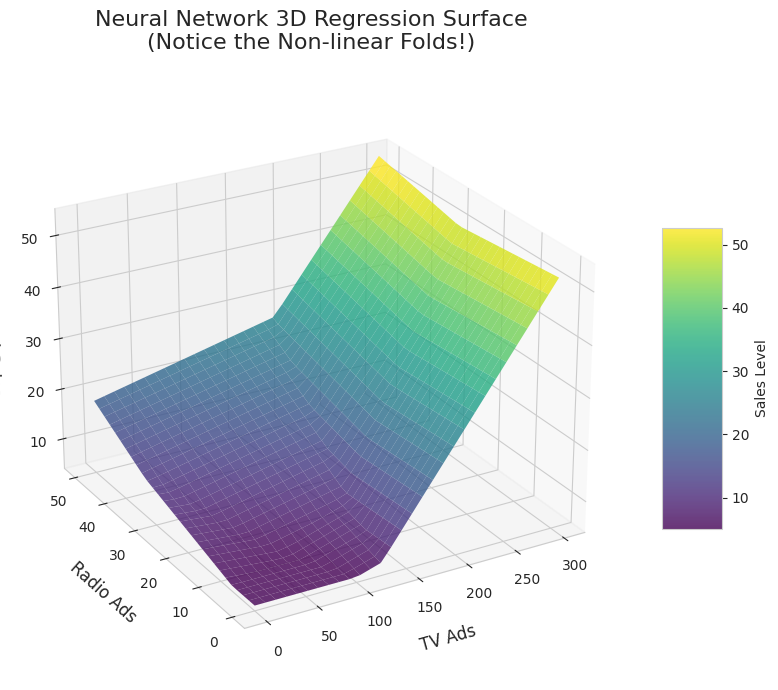

In [4]:
# TV 광고비(0~300)와 라디오 광고비(0~50)에 대한 가상의 메쉬그리드 생성
tv_vals = np.linspace(0, 300, 30)
radio_vals = np.linspace(0, 50, 30)
TV_grid, Radio_grid = np.meshgrid(tv_vals, radio_vals)

# 신경망을 통과시키기 위해 데이터를 (900, 2) 형태로 평탄화
X_space = np.c_[TV_grid.ravel(), Radio_grid.ravel()]

# 전체 공간에 대한 신경망 예측 (Forward Pass)
Z1_space = np.dot(X_space, W1) + b1
H1_space = np.maximum(0, Z1_space)
Sales_pred = np.dot(H1_space, W2) + b2

# 다시 3D로 그리기 위해 원래의 그리드 모양(30x30)으로 복구
Sales_surf = Sales_pred.reshape(TV_grid.shape)

# 3D 시각화
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 신경망이 만들어낸 '꺾인' 예측 평면 그리기 (cmap을 추가하여 높낮이 강조)
surf = ax.plot_surface(TV_grid, Radio_grid, Sales_surf, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_title('Neural Network 3D Regression Surface\n(Notice the Non-linear Folds!)', fontsize=16, pad=20)
ax.set_xlabel('TV Ads', fontsize=12, labelpad=10)
ax.set_ylabel('Radio Ads', fontsize=12, labelpad=10)
ax.set_zlabel('Predicted Sales', fontsize=12, labelpad=10)

# 각도 조절 (꺾인 부분이 잘 보이도록)
ax.view_init(elev=25, azim=-120)
fig.colorbar(surf, shrink=0.5, aspect=5, label='Sales Level')

plt.tight_layout()
plt.show()